# Modelos de Islas y Mantenimiento de Diversidad (Coevolución Distribuida)



[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AxelSkrauba/applied-ai-engineering/blob/main/notebooks/05_algoritmos_geneticos/09_modelos_de_islas_y_diversidad.ipynb)



## Objetivos


- Comprender el fenómeno del colapso de la diversidad global en poblaciones panmícticas (únicas).
- Diseñar e implementar un **Modelo de Islas (Island Model)** para mantener nichos ecológicos separados.
- Programar lógicas de **Migración** (topologías, frecuencias y políticas de reemplazo).
- Demostrar empíricamente cómo la migración permite a las subpoblaciones escapar de óptimos locales profundos.



## Prerrequisitos


- Haber completado: [Estrategias Evolutivas (ES) y Evolución Diferencial (DE)](05_estrategias_evolutivas_y_de.ipynb).
- Comprensión de la métrica de diversidad (Desviación Estándar del Fitness).

---


## Configuración del Entorno


In [1]:
# @title *Esta celda clona el repositorio (en Colab) e importa las utilidades comunes*
import sys
import os

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    import subprocess
    REPO_NAME = "applied-ai-engineering"
    if not os.path.exists(REPO_NAME):
        subprocess.run(["git", "clone", f"https://github.com/AxelSkrauba/{REPO_NAME}.git"], check=True)
    os.chdir(f"/content/{REPO_NAME}")
    sys.path.append(f"/content/{REPO_NAME}")
else:
    # Repositorio en local, apuntar path a la raiz
    os.chdir(f"../../")

from utils.plots import setup_plot_style
setup_plot_style()

import numpy as np
import matplotlib.pyplot as plt
import random
import warnings
warnings.filterwarnings('ignore')

try:
    import deap
except ImportError:
    !pip install deap
from deap import base, creator, tools, algorithms

# Fijamos la semilla para reproducibilidad
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.1/93.1 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 866.9/866.9 kB 7.0 MB/s eta 0:00:00


## Introducción Teórica: El Colapso de la Diversidad Global



En los notebooks anteriores, vimos que algoritmos como el GA Clásico sufren de **Convergencia Prematura**. Cuando un individuo descubre un óptimo local "decente", su genética inunda la población. En pocas generaciones, todos los individuos son clones de este líder. La diversidad cae a cero y el algoritmo pierde su capacidad de explorar nuevas regiones.

Hasta ahora, asumimos que toda nuestra población vive en un único "continente" donde todos pueden cruzarse con todos. A esto se le llama **Modelo Panmíctico**.

### La Solución Biológica: Especiación Alopátrica


En la naturaleza, la diversidad se mantiene gracias a la geografía. Si separamos a una especie en varias islas, cada grupo evolucionará de forma independiente, adaptándose a su nicho ecológico particular.

En computación evolutiva, esto se traduce en el **Modelo de Islas (Island Model)**:
1. Dividimos nuestra población total $N$ en $K$ subpoblaciones (islas).
2. Cada isla evoluciona de forma totalmente independiente.
3. Cada cierto tiempo (Frecuencia de Migración), las islas intercambian un pequeño grupo de individuos (Migrantes).

> Si la Isla A se queda atrapada en un óptimo local, eventualmente recibirá un migrante de la Isla B (que está explorando otra región del espacio). Este migrante inyectará material genético radicalmente nuevo en la Isla A, dándole el "empujón" necesario para escapar de su trampa local.

## Arquitectura del Modelo de Islas



Para diseñar un Modelo de Islas, se deben definir cuatro parámetros clave:

1. **Topología de Red:** ¿Quién se comunica con quién?
   * *Anillo (Cíclica):* Isla 0 $\rightarrow$ Isla 1 $\rightarrow$ Isla 2 $\rightarrow$ Isla 0. (Lenta difusión, mantiene alta diversidad).
   * *Estrella:* Todas las islas se comunican con un hub central.
   * *Grafo Completo:* Todas se comunican con todas. (Rápida difusión, riesgo de convergencia global prematura).
2. **Frecuencia de Migración:** ¿Cada cuántas generaciones viajan los individuos? (Ej. cada 20 generaciones).
3. **Tasa de Migración:** ¿Cuántos individuos viajan? (Ej. 5 individuos).
4. **Política de Migración:**
   * *¿Quién viaja?* Típicamente, los mejores individuos de la isla origen.
   * *¿A quién reemplazan?* Típicamente, a los peores individuos de la isla destino.


## Desarrollo e Implementación en DEAP



Enfrentamos a nuestro algoritmo a la función de **Rastrigin**, pero en 50 Dimensiones. Ya la abordamos en notebooks anteriores, Rastrigin es famosa por tener miles de óptimos locales profundos. Es la trampa perfecta para causar convergencia prematura.

### 1. Configuración Base


In [2]:
DIMENSIONES = 50
BOUND_LOW, BOUND_UP = -5.12, 5.12

def rastrigin_nd(ind):
    x = np.array(ind)
    A = 10
    return (A * DIMENSIONES + np.sum(x**2 - A * np.cos(2 * np.pi * x)),)

# Limpieza de DEAP
for cls in ['FitnessMin', 'Individual']:
    if hasattr(creator, cls): delattr(creator, cls)

creator.create("FitnessMin", base.Fitness, weights=(-1.0,))
creator.create("Individual", list, fitness=creator.FitnessMin)

def crear_toolbox():
    """
    Función de fábrica que retorna un toolbox limpio.
    Vital para que cada isla tenga su propio entorno sin compartir referencias.
    """
    tb = base.Toolbox()
    tb.register("attr_float", random.uniform, BOUND_LOW, BOUND_UP)
    tb.register("individual", tools.initRepeat, creator.Individual, tb.attr_float, n=DIMENSIONES)
    tb.register("population", tools.initRepeat, list, tb.individual)

    tb.register("evaluate", rastrigin_nd)
    tb.register("mate", tools.cxUniform, indpb=0.5)

    # Mutación Gaussiana (indpb bajo porque tenemos 50 genes)
    tb.register("mutate", tools.mutGaussian, mu=0, sigma=0.5, indpb=0.05)
    tb.register("select", tools.selTournament, tournsize=3)

    def limitar_dominio(func):
        def wrapper(*args, **kwargs):
            resultados = func(*args, **kwargs)
            for ind in resultados:
                for i in range(len(ind)):
                    ind[i] = max(BOUND_LOW, min(BOUND_UP, ind[i]))
            return resultados
        return wrapper

    tb.decorate("mate", limitar_dominio)
    tb.decorate("mutate", limitar_dominio)

    return tb

### 2. Experimento: Presupuesto Masivo vs. Presupuesto Restringido

Para entender el verdadero poder del Modelo de Islas, debemos analizarlo desde dos ángulos: el algorítmico y el computacional. Realizamos dos comparativas justas, manteniendo el mismo número total de individuos en ambos enfoques.

*   **Escenario A (Presupuesto Masivo - $N_{total} = 400$):**
    *   Isla Única: 400 individuos.
    *   Archipiélago: 4 islas de 100 individuos.
*   **Escenario B (Presupuesto Restringido - $N_{total} = 100$):**
    *   Isla Única: 100 individuos.
    *   Archipiélago: 4 islas de 25 individuos.

In [6]:
# --- ESCENARIO A: ISLA ÚNICA ---
def correr_isla_unica(N=400, G=300):
    tb = crear_toolbox()
    pop = tb.population(n=N)
    stats = tools.Statistics(lambda ind: ind.fitness.values[0])
    stats.register("min", np.min)

    pop, log = algorithms.eaSimple(pop, tb, cxpb=0.8, mutpb=0.2, ngen=G, stats=stats, verbose=False)
    return log.select("min")

# --- ESCENARIO B: MODELO DE ISLAS (Topología en Anillo) ---
def correr_modelo_islas(K=4, N_por_isla=100, G=300, freq_migracion=50, n_migrantes=5):
    # Inicializamos K islas independientes
    islas = []
    toolboxes = []
    historias = [[] for _ in range(K)]
    historia_global = []

    for _ in range(K):
        tb = crear_toolbox()
        pop = tb.population(n=N_por_isla)
        # Evaluación inicial
        for ind in pop:
            ind.fitness.values = tb.evaluate(ind)
        islas.append(pop)
        toolboxes.append(tb)

    for gen in range(G):
        mejor_global_gen = float('inf')

        # 1. Evolución independiente de cada isla
        for i in range(K):
            tb = toolboxes[i]
            pop = islas[i]

            # Un paso de eaSimple manual
            offspring = tb.select(pop, len(pop))
            offspring = list(map(tb.clone, offspring))

            for child1, child2 in zip(offspring[::2], offspring[1::2]):
                if random.random() < 0.8:
                    tb.mate(child1, child2)
                    del child1.fitness.values
                    del child2.fitness.values

            for mutant in offspring:
                if random.random() < 0.2:
                    tb.mutate(mutant)
                    del mutant.fitness.values

            invalid_ind = [ind for ind in offspring if not ind.fitness.valid]
            for ind in invalid_ind:
                ind.fitness.values = tb.evaluate(ind)

            islas[i] = offspring

            # Guardamos estadísticas
            mejor_isla = min([ind.fitness.values[0] for ind in islas[i]])
            historias[i].append(mejor_isla)
            if mejor_isla < mejor_global_gen:
                mejor_global_gen = mejor_isla

        historia_global.append(mejor_global_gen)

        # 2. Evento de Migración (Topología en Anillo: 0->1, 1->2, 2->3, 3->0)
        if gen > 0 and gen % freq_migracion == 0:
            migrantes_por_isla = []
            # Seleccionamos a los mejores para viajar
            for i in range(K):
                mejores = tools.selBest(islas[i], n_migrantes)
                # Clonamos para no compartir referencias en memoria
                migrantes_por_isla.append(list(map(toolboxes[i].clone, mejores)))

            # Realizamos el intercambio
            for i in range(K):
                isla_destino = (i + 1) % K
                migrantes_entrantes = migrantes_por_isla[i]

                # Ordenamos la isla destino de mejor a peor
                islas[isla_destino].sort(key=lambda ind: ind.fitness.values[0])

                # Reemplazamos a los peores (los últimos de la lista) con los migrantes
                islas[isla_destino][-n_migrantes:] = migrantes_entrantes

    return historia_global, historias

# Ejecutamos los experimentos
G_TOTAL = 300
FREQ_MIGRACION = 50

print("Ejecutando Escenario A (Presupuesto Masivo: N_total = 400)...")
hist_unica_400 = correr_isla_unica(N=400, G=G_TOTAL)
hist_global_islas_100, hist_islas_indiv_100 = correr_modelo_islas(K=4, N_por_isla=100, G=G_TOTAL, freq_migracion=FREQ_MIGRACION)

print("Ejecutando Escenario B (Presupuesto Restringido: N_total = 100)...")
hist_unica_100 = correr_isla_unica(N=100, G=G_TOTAL)
hist_global_islas_25, hist_islas_indiv_25 = correr_modelo_islas(K=4, N_por_isla=25, G=G_TOTAL, freq_migracion=FREQ_MIGRACION, n_migrantes=2)

print("Experimentos finalizados.")

Ejecutando Escenario A (Presupuesto Masivo: N_total = 400)...
Ejecutando Escenario B (Presupuesto Restringido: N_total = 100)...
Experimentos finalizados.


## Visualización y Diagnóstico


Graficamos ambos escenarios en una cuadrícula de 2x2. La fila superior mostrará el escenario masivo, y la fila inferior el escenario restringido. Prestar especial atención a las gráficas de la derecha, donde vemos el comportamiento individual de cada isla y cómo reaccionan a los eventos de migración.

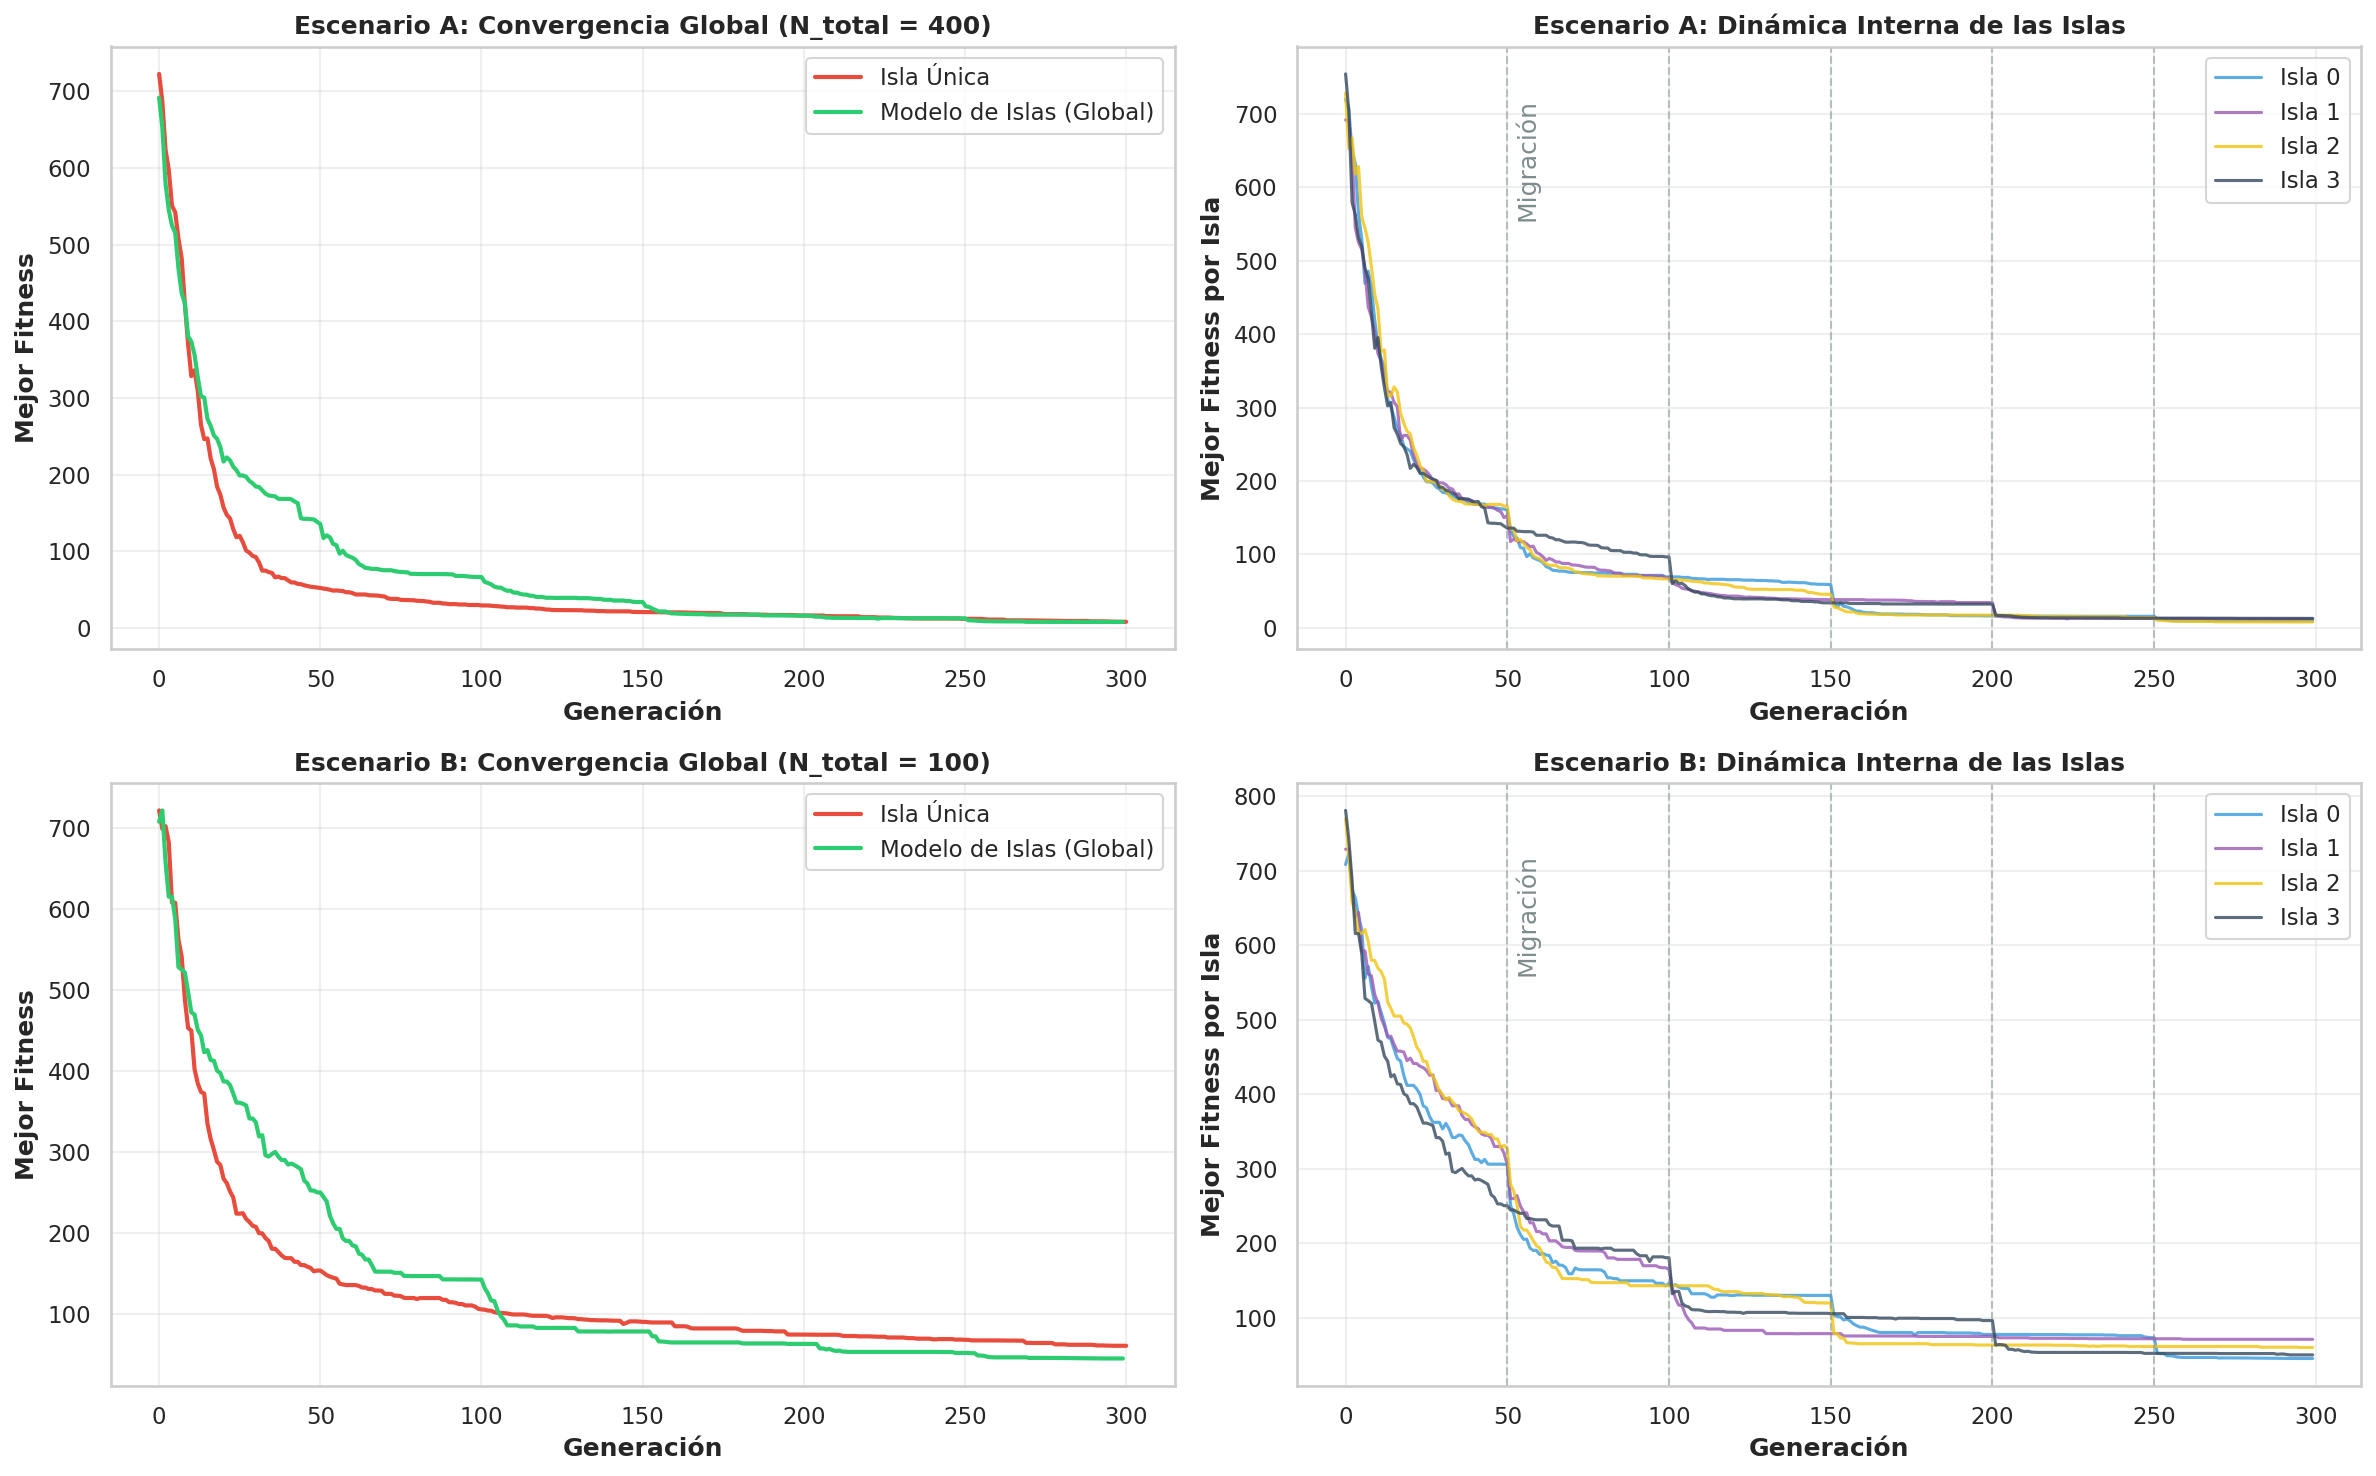

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

def plot_comparativa(ax, hist_unica, hist_islas, titulo):
    ax.plot(hist_unica, label='Isla Única', color='#e74c3c', lw=2)
    ax.plot(hist_islas, label='Modelo de Islas (Global)', color='#2ecc71', lw=2)
    ax.set_title(titulo, fontsize=12, fontweight='bold')
    ax.set_xlabel("Generación")
    ax.set_ylabel("Mejor Fitness")
    ax.legend()
    ax.grid(True, alpha=0.3)

def plot_dinamica(ax, hist_indiv, titulo):
    colores_islas = ['#3498db', '#9b59b6', '#f1c40f', '#34495e']
    for i in range(4):
        ax.plot(hist_indiv[i], label=f'Isla {i}', color=colores_islas[i], lw=1.5, alpha=0.8)
    for gen in range(FREQ_MIGRACION, G_TOTAL, FREQ_MIGRACION):
        ax.axvline(x=gen, color='#7f8c8d', linestyle='--', lw=1, alpha=0.5)
    ax.text(FREQ_MIGRACION + 2, max(hist_indiv[0]), 'Migración', color='#7f8c8d', rotation=90, va='top')
    ax.set_title(titulo, fontsize=12, fontweight='bold')
    ax.set_xlabel("Generación")
    ax.set_ylabel("Mejor Fitness por Isla")
    ax.legend()
    ax.grid(True, alpha=0.3)

# Fila 1: Escenario A (Masivo)
plot_comparativa(axes[0, 0], hist_unica_400, hist_global_islas_100, "Escenario A: Convergencia Global (N_total = 400)")
plot_dinamica(axes[0, 1], hist_islas_indiv_100, "Escenario A: Dinámica Interna de las Islas")

# Fila 2: Escenario B (Restringido)
plot_comparativa(axes[1, 0], hist_unica_100, hist_global_islas_25, "Escenario B: Convergencia Global (N_total = 100)")
plot_dinamica(axes[1, 1], hist_islas_indiv_25, "Escenario B: Dinámica Interna de las Islas")

plt.tight_layout()
plt.show()

### Discusión de Resultados:


Estas gráficas resumen lo importante sobre el diseño de arquitecturas evolutivas. El Modelo de Islas nos ofrece dos ventajas distintas dependiendo del contexto de nuestros recursos:

#### 1. Ventaja Computacional (Escenario A - Fila Superior)

Si miramos la gráfica superior izquierda, la Isla Única (rojo) bajó más rápido y llegó al mismo óptimo que el Modelo de Islas (verde). ¿Por qué? Porque $N=400$ es una población grande (y adecuada) para este problema. Tenía suficiente diversidad genética para resolver el problema por fuerza bruta sin estancarse.
*   **¿Fracasaron las islas? ¡No!** La gráfica X mide *Generaciones*, no *Tiempo*. Evaluar 400 individuos en un solo bucle toma 4 veces más tiempo que evaluar 100. El Modelo de Islas es ***Embarrassingly Parallel*** (Vergonzosamente Paralelizable). En la industria, podríamos desplegar cada isla en un servidor distinto (*evolucionan a máxima velocidad en paralelo, y solo se comunican por red cada 50 generaciones enviando un pequeño archivo JSON con los 5 migrantes*). Aunque la línea verde necesite más *generaciones* para igualar a la roja, en **tiempo de reloj (Wall-clock time)**, el Modelo de Islas terminará muchísimo antes.

#### 2. Ventaja Algorítmica (Escenario B - Fila Inferior)


Aquí es donde la estrategia brilla. Cuando restringimos el presupuesto a $N=100$, la Isla Única (rojo) sufre de **Convergencia Prematura**. Pierde su diversidad rápidamente y se estanca alrededor de un fitness de 50.
*   **El Rescate Genético:** Observa la línea verde (Islas). Al principio baja más lento (porque cada isla tiene solo 25 individuos), pero eventualmente **cruza y supera a la Isla Única**.
*   **¿Por qué ocurrió esto?** Mirar la dinámica interna (inferior derecha). Las islas pequeñas se estancan rápidamente en óptimos locales distintos. Pero al cruzar la línea de migración, intercambian individuos. La Isla 0 (que descubrió buenos genes para las dimensiones $x_1$ a $x_{10}$) se cruza con los migrantes de la Isla 1 (que descubrió buenos genes para $x_{11}$ a $x_{20}$). El cruce uniforme ensambla estos **Building Blocks** (bloques de construcción), provocando caídas verticales en el fitness.

**NOTA**: ¿esto pasa siempre? Definitivamente no, en ocasiones la Isla Única converge rápido y al resultado buscado. Pero el objetivo, es maximizar las posibilidades de hallar el mejor resultado al ejecutar el algoritmo.



> 💡 **Criterio de Ingeniería:**
> * Si se tienen recursos "infinitos", usar el Modelo de Islas para **paralelizar** y ahorrar tiempo.
> * Si se tienen recursos limitados (evaluaciones muy costosas), usar el Modelo de Islas para **proteger la diversidad** en nichos aislados y evitar la convergencia prematura.

## Conexiones y Próximos Pasos


Con este notebook, cerramos formalmente el bloque de algoritmos puramente evolutivos y de enjambres. Tenemos herramientas para espacios continuos, discretos, multiobjetivo, evolución de código (GP) y arquitecturas distribuidas.

Sin embargo, si venimos del mundo del Deep Learning, nace una pregunta inevitable: *"Todo esto es genial para funciones matemáticas y Random Forests, pero... ¿puedo usar un Algoritmo Genético para entrenar una Red Neuronal?"*

En el próximo y último notebook teórico, abordamos las bases de esto de manera simple.

- ➡️ **Siguiente:** [Algoritmos Meméticos y Neuroevolución (El Puente al Deep Learning)](10_algoritmos_memeticos_y_neuroevolucion.ipynb)
- 🔄 **Relacionado:** [Optimización Multiobjetivo y Frentes de Pareto (NSGA-II)](08_optimizacion_multiobjetivo_nsga2.ipynb)

## Referencias


### Artículos Fundacionales

1. **Whitley, D., Rana, S., & Heckendorn, R. B. (1999)**. *The Island Model Genetic Algorithm: On Separability, Population Size and Convergence*. Journal of Computing and Information Technology.  
   (**Paper clásico** sobre el Modelo de Islas).

2. **Cantú-Paz, E. (1998)**. *A Survey of Parallel Genetic Algorithms*. Calculateurs Parallèles, Réseaux et Systèmes Répartis.  
   (Revisión de modelos distribuidos).

3. **Gong, Y.-J., et al. (2015)**. *Distributed Evolutionary Algorithms and Their Models: A Survey of the State-of-the-Art*. Applied Soft Computing.  
   (Revisión moderna de arquitecturas distribuidas).

---


## Entorno de Ejecución


In [5]:
from utils.environment import environment_table
environment_table()

Package,Version
Python,3.12.13
Platform,Linux-6.6.122+-x86_64-with-glibc2.35
IPython,7.34.0
deap,1.4
ipywidgets,7.7.1
matplotlib,3.10.0
numpy,2.0.2
pandas,2.2.2
scipy,1.16.3
seaborn,0.13.2
